# Практика 7 — хі-квадрат тести для категоріальних даних

**Applied Statistics · KSE** · Ihor Miroshnychenko

Відкрийте цей зошит у Google Colab і виконуйте комірки згори вниз (Runtime → Run all, або Shift+Enter по черзі). Усі бібліотеки (numpy, scipy, matplotlib, statsmodels) у Colab уже встановлені — копіювати код нікуди не потрібно.

Блоки **Спершу вгадайте** і **Ваша черга** — для вас: запишіть свою відповідь, перш ніж дивитись розв'язання нижче.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2, chisquare, chi2_contingency, fisher_exact
from statsmodels.stats.proportion import proportion_confint

np.random.seed(73)

turquoise = "#20B2AA"
red       = "#fb6107"
blue      = "#181485"
green     = "#8bb174"
gray      = "#A0A0A0"
red_pink  = "#e64173"
orange    = "#FFA500"
slate     = "#314f4f"

# Що ми робимо сьогодні

Минулі практики працювали з **числовими** метриками (ARPU, час до події).
Але половина продуктових даних --- це **підрахунки за категоріями**: день
тижня, обрана кухня, місто, «конвертувався / ні». Сьогодні --- інструмент
саме для такого, і всі його різновиди зводяться до **однієї** статистики:

$$
\tau = \sum_{\text{клітинки}} \frac{(O - E)^2}{E},
$$

де $O$ --- спостережені частоти, $E$ --- очікувані за гіпотезою.

Ми будуємо **гардрейли для категоріальних A/B та аналітики** застосунку
доставки **GreenBowl** (той самий, що в Практиках 4–6) і відповідаємо на
чотири прикладні питання:

1. **Чи рівномірний попит** по днях тижня (планування змін кухарів)?
2. **Чи залежить вибір кухні від міста** (асортимент під регіон)?
3. **Чи змінив A/B-редизайн меню** розподіл замовлень по категоріях?
4. **Чи спрацював промо-пілот** у новому місті на **малій** вибірці?

## Правила гри
- Ми **будуємо** інструмент `gof_test → assoc_test → assoc_report →
  safe_assoc` крок за кроком; самі критерії беремо готові
  (`scipy.stats.chisquare`, `chi2_contingency`, `fisher_exact`).
- Кожна версія --- **розширення** попередньої й **перевикористовує** її.
- Перед кожним кейсом є блок **🔮 «Спершу вгадайте»** --- запишіть свою
  відповідь, перш ніж запускати код.
- Після кожного --- **«Ваша черга»** з мінізадачею і згорнутим
  розв'язанням, плюс одна задача-**кейс** із бізнес-рішенням.
- Де треба перевірити *сам критерій*, повертаємось до **Монте-Карло** з
  Практики 5.

---

# Кейс: категоріальні дані GreenBowl

Усі дані ми **генеруємо самі** --- так ми завжди знаємо «правду» і можемо
перевірити, чи критерій її ловить. Базові категорії:

In [2]:
DAYS     = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Нд"]
CUISINES = ["Піца", "Суші", "Бургери", "Салати", "Десерти"]
CITIES   = ["Київ", "Львів", "Одеса", "Харків"]

def order_counts(probs, n, seed=None):
    """n замовлень, розкиданих по категоріях із імовірностями probs."""
    probs = np.asarray(probs, float)
    probs = probs / probs.sum()
    return np.random.default_rng(seed).multinomial(n, probs)

Одна функція `order_counts` --- наш «генератор логів»: ми задаємо
**справжні** ймовірності категорій, а вона повертає спостережені частоти.

---

# Частина I --- Goodness-of-fit: чи рівномірний попит?

> **Кейс.** Операційний менеджер ставить однакову кількість кухарів на
> кожен день тижня. Аналітик підозрює, що попит **нерівномірний**, і
> зміни треба перерозподілити. За тиждень --- 1400 замовлень.

## 🔮 Спершу вгадайте
Подивіться на частоти по днях нижче (Пн…Нд). **Не рахуючи нічого**,
запишіть: ви відхилите гіпотезу «попит рівномірний» на рівні 5%? Так чи
ні?

## Версія 1 --- вердикт узгодженості

In [3]:
def gof_test(observed, p0=None, alpha=0.05):
    """Версія 1. χ²-критерій узгодженості.

    observed --- спостережені частоти за k категоріями.
    p0       --- очікувані ймовірності (None → рівномірний розподіл).
    """
    observed = np.asarray(observed, float)
    n, k = observed.sum(), len(observed)
    if p0 is None:
        p0 = np.full(k, 1 / k)
    expected = n * np.asarray(p0, float)
    res = chisquare(observed, f_exp=expected)
    verdict = ("⛔ відхиляємо H0 → розподіл НЕ такий, як гадали"
               if res.pvalue <= alpha else
               "✅ не відхиляємо H0 → дані узгоджуються з гіпотезою")
    return {"chi2": res.statistic, "df": k - 1, "p": res.pvalue,
            "min_expected": expected.min(), "verdict": verdict}

Застосуємо до попиту по днях. H0: попит рівномірний (по $1/7$ на день).

Замовлень по днях: {'Пн': np.int64(173), 'Вт': np.int64(151), 'Ср': np.int64(190), 'Чт': np.int64(190), 'Пт': np.int64(212), 'Сб': np.int64(251), 'Нд': np.int64(233)}
χ² = 35.82,  df = 6,  p = 0.0000
⛔ відхиляємо H0 → розподіл НЕ такий, як гадали


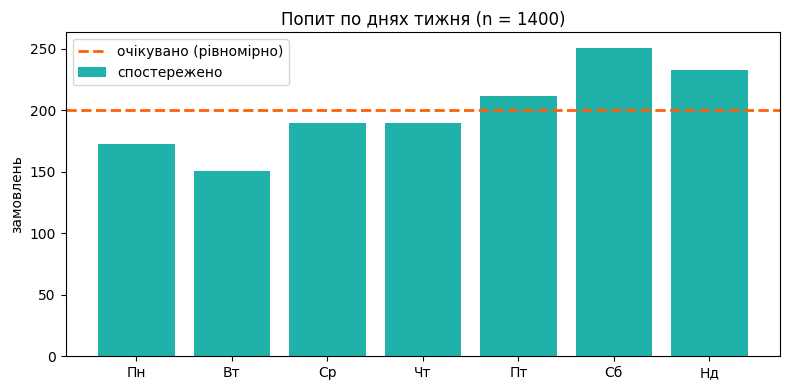

In [4]:
orders = order_counts([0.13, 0.12, 0.13, 0.13, 0.15, 0.18, 0.16],
                       n=1400, seed=7)

r = gof_test(orders)            # p0=None → перевіряємо рівномірність
print("Замовлень по днях:", dict(zip(DAYS, orders)))
print(f"χ² = {r['chi2']:.2f},  df = {r['df']},  p = {r['p']:.4f}")
print(r["verdict"])

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(DAYS, orders, color=turquoise, label="спостережено")
ax.axhline(orders.mean(), color=red, ls="--", lw=2,
           label="очікувано (рівномірно)")
ax.set_ylabel("замовлень"); ax.set_title("Попит по днях тижня (n = 1400)")
ax.legend()
plt.tight_layout()
plt.show()

Сплеск п'ятниця–субота-неділя «перетягує» статистику: $p < 0{,}05$, попит
**не** рівномірний. Рекомендація операційці: підсилити зміни на вихідні.

## Ваша черга 1
1. Згенеруйте тиждень із **справді** рівномірним попитом
   (`order_counts([1]*7, 1400, seed=3)`) і прогоніть `gof_test`. Чи
   тримає критерій обіцянку (великий $p$)?
2. Менеджер каже: «Та різниця ж копійчана!». Порахуйте, на **скільки %**
   найзавантаженіший день перевищує найтихіший. Чи варто через це
   рухати зміни?
3. **Кейс.** Маркетинг очікував розподіл кухонь
   $[0{,}30; 0{,}20; 0{,}25; 0{,}15; 0{,}10]$ (Піца…Десерти), а за тиждень
   побачив `[640, 290, 500, 240, 130]`. Перевірте `gof_test(obs, p0=...)`:
   асортимент відповідає очікуванням?

## Розв'язання 1

In [5]:
# (1) справді рівномірний попит
uni = order_counts([1] * 7, 1400, seed=3)
print("Рівномірний:", gof_test(uni)["verdict"], f"(p={gof_test(uni)['p']:.3f})")

# (2) розмах завантаження
print(f"Пік/мінімум: +{(orders.max()/orders.min() - 1):.0%}")

# (3) асортимент кухонь проти плану
obs = np.array([640, 290, 500, 240, 130])
r = gof_test(obs, p0=[0.30, 0.20, 0.25, 0.15, 0.10])
print(f"\nКухні vs план: χ²={r['chi2']:.2f}, p={r['p']:.4f} → {r['verdict']}")

Рівномірний: ✅ не відхиляємо H0 → дані узгоджуються з гіпотезою (p=0.919)
Пік/мінімум: +66%

Кухні vs план: χ²=54.91, p=0.0000 → ⛔ відхиляємо H0 → розподіл НЕ такий, як гадали


**Інтерпретація.** Рівномірний тиждень дає великий $p$ --- критерій не
б'є хибну тривогу. Пік на ~60% вищий за мінімум --- це вже операційно
відчутно, тож статистична значущість тут збігається з практичною. Для
кухонь $p$ підкаже, чи відхилення від плану --- це шум, чи реальний зсув
попиту.

---

# Правило очікуваних частот --- і чому воно існує

χ² спирається на нормальне наближення (ЦГТ), яке **ламається на рідкісних
категоріях**. Правило: кожна **очікувана** частота $E_i \ge 5$. Перевіримо
це не на віру, а **Монте-Карло**: чи тримає критерій 5% хибних спрацювань,
коли одна категорія дуже рідкісна?

In [6]:
def gof_fpr(probs, n, n_exps=4000, seed=73):
    """FPR критерію узгодженості під H0 (дані з тих самих probs)."""
    rng = np.random.default_rng(seed)
    expected = n * np.asarray(probs, float)
    rej = sum(chisquare(rng.multinomial(n, probs), f_exp=expected).pvalue < 0.05
              for _ in range(n_exps))
    lo, hi = proportion_confint(rej, n_exps, alpha=0.05, method="wilson")
    return {"fpr": rej / n_exps, "ci": (lo, hi), "min_expected": expected.min()}

healthy = [0.20, 0.20, 0.20, 0.20, 0.20]      # усі категорії «жирні»
rare    = [0.485, 0.485, 0.01, 0.01, 0.01]    # три рідкісні категорії

for probs, name in [(healthy, "здорові категорії"), (rare, "є рідкісні")]:
    r = gof_fpr(probs, n=60)
    print(f"{name:18s}: FPR={r['fpr']:.3f}  "
          f"CI=({r['ci'][0]:.3f},{r['ci'][1]:.3f})  "
          f"E_min={r['min_expected']:.1f}")

здорові категорії : FPR=0.050  CI=(0.043,0.057)  E_min=12.0


є рідкісні        : FPR=0.081  CI=(0.073,0.090)  E_min=0.6


## Що показав Монте-Карло
Зі «здоровими» категоріями FPR лягає на $5\%$. Щойно з'являється категорія
з $E < 5$ (тут $E \approx 0{,}6$), критерій **перевищує** $\alpha$ ---
б'є хибну тривогу частіше, ніж обіцяв. Тому **об'єднуйте** рідкісні
категорії або беріть точний критерій. Правило стосується **очікуваних**
частот, не спостережених.

## Ваша черга 2
1. Знайдіть приблизно, з якого $n$ FPR для `rare` повертається до $\approx
   5\%$ (підказка: щоб $E \ge 5$ для категорії з $p=0{,}01$, треба $n \ge
   500$). Перевірте `gof_fpr(rare, n)`.
2. Об'єднайте три рідкісні категорії в одну (`[0.485, 0.485, 0.03]`) і
   повторіть при $n=60$. FPR повернувся під контроль?
3. **Кейс.** У логах GreenBowl категорія «Веганське» --- лише $1\%$
   замовлень. Як коректно включити її в `gof_test` по кухнях, не
   порушивши правило?

## Розв'язання 2

In [7]:
# (1) FPR відновлюється з ростом n
for n in (60, 300, 800):
    r = gof_fpr(rare, n)
    print(f"rare, n={n:>3d}: FPR={r['fpr']:.3f}  E_min={r['min_expected']:.1f}")

# (2) об'єднали рідкісні категорії
r = gof_fpr([0.485, 0.485, 0.03], n=60)
print(f"\nоб'єднані категорії, n=60: FPR={r['fpr']:.3f}  "
      f"E_min={r['min_expected']:.1f}")

rare, n= 60: FPR=0.081  E_min=0.6


rare, n=300: FPR=0.061  E_min=3.0


rare, n=800: FPR=0.051  E_min=8.0



об'єднані категорії, n=60: FPR=0.058  E_min=1.8


**Інтерпретація.** Збільшення $n$ або об'єднання рідкісних категорій
піднімає $E_i$ над 5 --- і FPR повертається до чесних 5%. Для «Веганського»
($1\%$) на тижневих даних варто або злити його з «Салатами», або
накопичити більше тижнів, щоб $E \ge 5$.

---

# Частина II --- Незалежність: кухня × місто

> **Кейс.** Продакт хоче знати, чи варто **локалізувати асортимент**: чи
> залежить вибір кухні від міста? Якщо ні --- одне меню на всіх; якщо так
> --- регіональні підбірки.

Тепер **дві** категоріальні змінні на тих самих замовленнях → **таблиця
спряженості**. Згенеруємо логи, де кухня **залежить** від міста:

In [8]:
def cuisine_city_table(seed=7):
    rng = np.random.default_rng(seed)
    base = np.array([0.30, 0.20, 0.25, 0.15, 0.10])     # Піца…Десерти
    mods = {                                            # смаки міст
        0: [1.0, 1.0, 1.0, 1.0, 1.0],   # Київ — як «база»
        1: [0.8, 0.7, 0.9, 1.4, 1.6],   # Львів — салати/десерти
        2: [0.9, 1.8, 0.8, 1.0, 0.9],   # Одеса — суші
        3: [1.3, 0.7, 1.4, 0.8, 0.8],   # Харків — піца/бургери
    }
    nper = [2500, 1800, 1500, 2000]
    rows = [rng.multinomial(nper[c], base * np.array(mods[c]) /
                            (base * np.array(mods[c])).sum()) for c in range(4)]
    return np.array(rows)

table = cuisine_city_table()
print("       " + "  ".join(f"{c:>7s}" for c in CUISINES))
for city, row in zip(CITIES, table):
    print(f"{city:>7s} " + "  ".join(f"{v:>7d}" for v in row))

          Піца     Суші  Бургери   Салати  Десерти
   Київ     749      486      649      389      227
  Львів     438      264      413      384      301
  Одеса     375      511      301      203      110
 Харків     710      274      632      233      151


## Версія 2 --- вердикт асоціації

In [9]:
def assoc_test(table, alpha=0.05):
    """Версія 2. χ²-критерій незалежності / однорідності для таблиці."""
    table = np.asarray(table, float)
    chi2_stat, p, dof, expected = chi2_contingency(table)
    verdict = ("⛔ відхиляємо незалежність → змінні ПОВ'ЯЗАНІ"
               if p <= alpha else
               "✅ не відхиляємо → зв'язку не видно")
    return {"chi2": chi2_stat, "df": dof, "p": p,
            "min_expected": expected.min(), "expected": expected,
            "verdict": verdict}

χ² = 487,  df = 12,  p = 1.3e-96
E_min = 152  (правило ≥5 виконано)
⛔ відхиляємо незалежність → змінні ПОВ'ЯЗАНІ


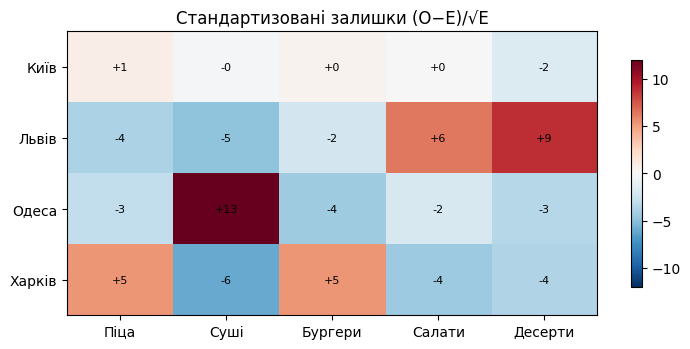

In [10]:
r = assoc_test(table)
print(f"χ² = {r['chi2']:.0f},  df = {r['df']},  p = {r['p']:.2g}")
print(f"E_min = {r['min_expected']:.0f}  (правило ≥5 виконано)")
print(r["verdict"])

# Де саме зв'язок? — стандартизовані залишки (O−E)/√E
resid = (table - r["expected"]) / np.sqrt(r["expected"])

fig, ax = plt.subplots(figsize=(7.5, 3.6))
im = ax.imshow(resid, cmap="RdBu_r", vmin=-12, vmax=12, aspect="auto")
ax.set_xticks(range(5)); ax.set_xticklabels(CUISINES)
ax.set_yticks(range(4)); ax.set_yticklabels(CITIES)
ax.set_title("Стандартизовані залишки (O−E)/√E")
for i in range(4):
    for j in range(5):
        ax.text(j, i, f"{resid[i, j]:+.0f}", ha="center", va="center",
                fontsize=8, color="black")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

$p \approx 0$ → кухня **залежить** від міста. Але χ² каже лише «так/ні».
Карта залишків показує **де**: Одеса --- червоне на «Суші», Львів --- на
«Десертах/Салатах», Харків --- на «Піці/Бургерах». Це вже **готова
підказка для локалізації меню**.

## Ваша черга 3
1. Поясніть бізнес-мовою **дві** найяскравіші клітинки карти залишків. Яку
   кухню в якому місті варто винести в топ застосунку?
2. Виберіть із таблиці лише **дві** кухні (`table[:, [1, 2]]` --- Суші,
   Бургери) і прогоніть `assoc_test`. Зв'язок із містом зберігається?
3. **Кейс.** Якби `assoc_test` дав **великий** $p$ (зв'язку немає), яке
   рішення прийняв би продакт щодо меню --- і скільки б це зекономило?

## Розв'язання 3

In [11]:
# (2) лише Суші та Бургери
sub = table[:, [1, 2]]
r = assoc_test(sub)
print("Суші+Бургери vs місто:", r["verdict"], f"(p={r['p']:.2g})")

Суші+Бургери vs місто: ⛔ відхиляємо незалежність → змінні ПОВ'ЯЗАНІ (p=4.3e-42)


**Інтерпретація.** Найяскравіші клітинки --- Одеса×Суші та Львів×Десерти:
саме їх варто підсвічувати в локальних добірках. Зв'язок зберігається й на
підтаблиці. Якби $p$ був великим --- одне глобальне меню, без витрат на
регіональні асортименти й окремі закупівлі; рішення «не локалізувати»
теж цінне, бо економить операційку.

---

# Великі дані: значущо ≠ сильно (Cramér's V)

На великих $n$ $p$-value майже **завжди** мізерний --- значущість
гарантована й нічого не каже про **силу** зв'язку. Потрібен **розмір
ефекту**: Cramér's V.

## Версія 3 --- асоціація + сила ефекту

In [12]:
def assoc_report(table, alpha=0.05):
    """Версія 3. assoc_test + Cramér's V та словесна сила зв'язку."""
    r = assoc_test(table, alpha)                 # ← перевикористали Версію 2
    table = np.asarray(table, float)
    n = table.sum()
    V = np.sqrt(r["chi2"] / (n * (min(table.shape) - 1)))
    strength = ("практично відсутній" if V < 0.1 else
                "слабкий"  if V < 0.2 else
                "помірний" if V < 0.4 else "сильний")
    r.update({"n": int(n), "cramer_v": V, "strength": strength})
    return r

In [13]:
r = assoc_report(table)
print(f"Кухня × місто:  n={r['n']},  p={r['p']:.2g},  "
      f"Cramér's V={r['cramer_v']:.3f} → зв'язок {r['strength']}")

Кухня × місто:  n=7800,  p=1.3e-96,  Cramér's V=0.144 → зв'язок слабкий


Тепер --- пастка великих даних. Уявімо, що ми порівнюємо частку повторних
замовлень у двох когортах по **мільйону** користувачів кожна, де реальна
різниця --- лише $50\%$ проти $51\%$:

In [14]:
rng = np.random.default_rng(1)
big = np.array([rng.multinomial(1_000_000, [0.50, 0.50]),
                rng.multinomial(1_000_000, [0.49, 0.51])])
r = assoc_report(big)
print(f"Мега-таблиця: n={r['n']:,}")
print(f"  p = {r['p']:.2g}   → {r['verdict']}")
print(f"  Cramér's V = {r['cramer_v']:.4f} → зв'язок {r['strength']}")

Мега-таблиця: n=2,000,000
  p = 3.8e-50   → ⛔ відхиляємо незалежність → змінні ПОВ'ЯЗАНІ
  Cramér's V = 0.0105 → зв'язок практично відсутній


## Спіймай помилку 🕵️
**Аналітик А:** «$p < 10^{-20}$ --- редизайн дав потужний ефект на
повторні замовлення, викочуємо на всіх!»
**Аналітик Б:** «$V = 0{,}01$ --- ефект мікроскопічний, різниця $50$ vs
$51\%$. Значущо, але не варте розробки».
**Хто правий?** На великих $n$ правий **Б**: $p$ міряє «чи є різниця», а
не «чи вона велика». Завжди показуйте $p$ **і** розмір ефекту.

## Ваша черга 4
1. Збільшуйте реальну різницю (`[0.45, 0.55]`, потім `[0.40, 0.60]`) при
   тому ж $n$. Як росте Cramér's V і коли зв'язок стає «помірним»?
2. Зменшіть $n$ кожної когорти до $2000$ при різниці $50$ vs $51\%$. Що
   тепер каже $p$ --- і чи змінився Cramér's V? Який висновок про роль $n$?
3. **Кейс.** Менеджер вимагає «статистично значущий результат». Поясніть
   на цьому прикладі, чому це **не та** вимога, і що просити натомість.

## Розв'язання 4

In [15]:
rng = np.random.default_rng(2)
# (1) зростання ефекту при фіксованому n
for q in (0.51, 0.55, 0.60):
    t = np.array([rng.multinomial(1_000_000, [0.50, 0.50]),
                  rng.multinomial(1_000_000, [1 - q, q])])
    r = assoc_report(t)
    print(f"різниця 50 vs {q*100:.0f}%:  V={r['cramer_v']:.3f} → {r['strength']}")

# (2) той самий слабкий ефект, але мале n
small = np.array([rng.multinomial(2000, [0.50, 0.50]),
                  rng.multinomial(2000, [0.49, 0.51])])
r = assoc_report(small)
print(f"\nрізниця 50 vs 51%, n=2000:  p={r['p']:.3f} → {r['verdict']}")
print(f"  Cramér's V={r['cramer_v']:.4f} (той самий слабкий ефект)")

різниця 50 vs 51%:  V=0.011 → практично відсутній
різниця 50 vs 55%:  V=0.050 → практично відсутній
різниця 50 vs 60%:  V=0.100 → практично відсутній

різниця 50 vs 51%, n=2000:  p=0.569 → ✅ не відхиляємо → зв'язку не видно
  Cramér's V=0.0090 (той самий слабкий ефект)


**Інтерпретація.** Cramér's V росте з **реальною** різницею і **не**
залежить від $n$ --- це властивість розміру ефекту. А $p$ залежить від $n$:
на $2000$ той самий слабкий зв'язок уже **не** значущий. Тож «дайте
значущий результат» --- хибна вимога: на великих даних значущим стане
будь-що. Просити треба **розмір ефекту** + чи він перевищує
бізнес-поріг.

---

# Частина III --- Однорідність: A/B меню

> **Кейс.** A/B-тест нового **розкладу меню**. Контроль бачить старий,
> тест --- новий. Для кожного замовлення фіксуємо **категорію кошика**:
> Економ / Стандарт / Великий / Преміум. Чи **змінив** редизайн розподіл
> по категоріях?

Ключова ідея лекції: якщо вважати **групу** (тест/контроль) другою
змінною, таблиця однорідності --- це звичайна таблиця спряженості. Тож той
самий `assoc_report` працює без змін.

## 🔮 Спершу вгадайте
Спочатку запустимо **A/A** (обидві групи з одного пулу, ефекту немає).
Яким, по-вашому, має бути вердикт --- відхилити чи ні?

In [16]:
rng = np.random.default_rng(11)
basket_p = [0.45, 0.30, 0.18, 0.07]          # Економ/Стандарт/Великий/Преміум
N = 6000
cats = rng.choice(4, size=N, p=basket_p)
perm = rng.permutation(N)
A = np.bincount(cats[perm[:N // 2]], minlength=4)   # чесний випадковий поділ
B = np.bincount(cats[perm[N // 2:]], minlength=4)

r = assoc_report(np.array([A, B]))
print("A/A (немає ефекту):", r["verdict"], f"(p={r['p']:.3f})")

A/A (немає ефекту): ✅ не відхиляємо → зв'язку не видно (p=0.584)


A/A не відхиляється --- гардрейл рандомізації чистий. Тепер **справжній**
ефект: новий розклад зсуває частину кошиків у бік «Великий/Преміум».

A/B (новий розклад):  p=0.0000,  Cramér's V=0.081 → ⛔ відхиляємо незалежність → змінні ПОВ'ЯЗАНІ


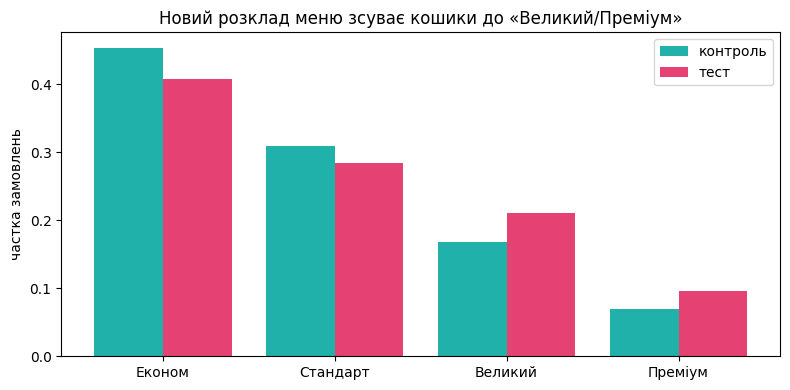

In [17]:
shift_cats = rng.choice(4, size=N // 2, p=[0.40, 0.30, 0.21, 0.09])
B2 = np.bincount(shift_cats, minlength=4)

r = assoc_report(np.array([A, B2]))
print(f"A/B (новий розклад):  p={r['p']:.4f},  "
      f"Cramér's V={r['cramer_v']:.3f} → {r['verdict']}")

labels = ["Економ", "Стандарт", "Великий", "Преміум"]
x = np.arange(4)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - 0.2, A / A.sum(), 0.4, color=turquoise, label="контроль")
ax.bar(x + 0.2, B2 / B2.sum(), 0.4, color=red_pink, label="тест")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("частка замовлень")
ax.set_title("Новий розклад меню зсуває кошики до «Великий/Преміум»")
ax.legend()
plt.tight_layout()
plt.show()

## Чому не $t$-тест?
Тут метрика --- **категорія**, а не число. $t$-тест по «середній
категорії» не має сенсу. χ²-однорідність порівнює **весь розподіл** по
категоріях --- саме те, що треба для зсуву структури замовлень.

## Ваша черга 5
1. Порахуйте **частку Преміум** у контролі й тесті. На скільки в.п. вона
   зросла? Чи варта така зміна викочування?
2. Зробіть ефект **дуже слабким** (`[0.44, 0.30, 0.18, 0.08]`) і подивіться
   $p$ та Cramér's V при $N=6000$. А при $N=60000$? Звідки знайома пастка?
3. **Кейс.** Окрім зсуву категорій, команда хоче знати, чи зросла **частка
   Преміум** конкретно. Який критерій тут точніший за χ² --- і чому?

## Розв'язання 5

In [18]:
# (1) приріст частки Преміум
print(f"Преміум: контроль={A[3]/A.sum():.1%}, тест={B2[3]/B2.sum():.1%} "
      f"(+{(B2[3]/B2.sum() - A[3]/A.sum())*100:.1f} в.п.)")

# (2) слабкий ефект на різних n
rng = np.random.default_rng(12)
for size in (6000, 60000):
    a = np.bincount(rng.choice(4, size, p=basket_p), minlength=4)
    b = np.bincount(rng.choice(4, size, p=[0.44, 0.30, 0.18, 0.08]), minlength=4)
    r = assoc_report(np.array([a, b]))
    print(f"N={size:>6d}: p={r['p']:.3f}, V={r['cramer_v']:.3f} → {r['verdict']}")

Преміум: контроль=6.9%, тест=9.7% (+2.8 в.п.)
N=  6000: p=0.375, V=0.016 → ✅ не відхиляємо → зв'язку не видно
N= 60000: p=0.000, V=0.024 → ⛔ відхиляємо незалежність → змінні ПОВ'ЯЗАНІ


**Інтерпретація.** Слабкий ефект на $N=6000$ часто не значущий, а на
$N=60000$ --- значущий, хоча Cramér's V лишається крихітним: знову пастка
великого $n$. Для **частки Преміум** (одна бінарна метрика) точніший
$z$-тест для пропорцій: він заточений під один параметр, тоді як
χ²-однорідність «розмазує» чутливість по всіх чотирьох категоріях.

---

# Частина IV --- Малі вибірки: промо-пілот (Yates / Fisher)

> **Кейс.** Перед запуском у новому місті GreenBowl робить **мікро-пілот**:
> по $15$ користувачів у контролі й тесті, метрика --- «зробив повторне
> замовлення / ні». У тесті (з промокодом) повторили $6$, у контролі ---
> $1$. Промо спрацювало?

На таких малих частотах звичайний χ² **бреше** (роздуває значущість). Тому
фінальна версія інструменту сама перемикається на точний критерій.

## Версія 4 --- безпечний вибір критерію

In [19]:
def safe_assoc(table, alpha=0.05):
    """Версія 4. Малі очікувані частоти у 2×2 → точний критерій Фішера."""
    table = np.asarray(table, float)
    expected = chi2_contingency(table)[3]
    if table.shape == (2, 2) and expected.min() < 5:
        odds, p = fisher_exact(table)
        verdict = ("⛔ відхиляємо (Fisher)" if p <= alpha
                   else "✅ не відхиляємо (Fisher)")
        return {"test": "Fisher exact", "p": p, "odds_ratio": odds,
                "min_expected": expected.min(), "verdict": verdict}
    return {"test": "chi2", **assoc_report(table, alpha)}  # ← перевикористали В3

In [20]:
pilot = np.array([[6, 9],     # тест:     6 повторних, 9 ні
                  [1, 14]])   # контроль: 1 повторне, 14 ні

print("Наївний χ² без поправки: p =",
      f"{chi2_contingency(pilot, correction=False)[1]:.4f}  ⛔ 'значущо!'")
print("χ² з поправкою Йейтса:   p =",
      f"{chi2_contingency(pilot)[1]:.4f}")

r = safe_assoc(pilot)
print(f"\nsafe_assoc → {r['test']}: p={r['p']:.4f}  "
      f"(E_min={r['min_expected']:.1f})")
print(r["verdict"])

Наївний χ² без поправки: p = 0.0309  ⛔ 'значущо!'
χ² з поправкою Йейтса:   p = 0.0842

safe_assoc → Fisher exact: p=0.0801  (E_min=3.5)
✅ не відхиляємо (Fisher)


## Що сталося
Наївний χ² дав $p = 0{,}031$ --- «ефект є, викочуємо!». Але очікувані
частоти $< 5$, тож наближення некоректне. **Точний критерій Фішера** дає
$p = 0{,}08$: доказів **недостатньо**. На $15+15$ користувачів $6$ проти
$1$ повторного --- це ще може бути випадковість. Рішення: **не** робити
висновок, **набрати більшу вибірку**.

Перевіримо це **Монте-Карло**: на малих 2×2 під H0 (ефекту немає)
порівняємо FPR без поправки та з Йейтсом.

In [21]:
def fpr_2x2(n, correction, p=0.3, n_exps=4000, seed=73):
    """FPR χ² для 2×2 під H0 (обидві групи з тим самим p)."""
    rng = np.random.default_rng(seed)
    rej = 0
    for _ in range(n_exps):
        a, c = rng.binomial(n, p), rng.binomial(n, p)
        t = [[a, n - a], [c, n - c]]
        if (a + c) and (2 * n - a - c):
            rej += chi2_contingency(t, correction=correction)[1] < 0.05
    return rej / n_exps

for n in (8, 15, 30):
    print(f"n={n:>2d} на групу:  без поправки FPR={fpr_2x2(n, False):.3f}   "
          f"Йейтс FPR={fpr_2x2(n, True):.3f}")

n= 8 на групу:  без поправки FPR=0.051   Йейтс FPR=0.011


n=15 на групу:  без поправки FPR=0.052   Йейтс FPR=0.015


n=30 на групу:  без поправки FPR=0.047   Йейтс FPR=0.026


## Висновок Монте-Карло
Поправка Йейтса робить критерій **консервативним** (FPR помітно нижчий за
$5\%$) --- безпечно, ціна --- трохи потужності. На дуже малих частотах
точний критерій **Фішера** --- найнадійніший дефолт; χ² лишаємо для
великих таблиць.

## Ваша черга 6
1. Скільки повторних у тесті (при $1$ в контролі та $n=15$) потрібно, щоб
   Фішер дав $p < 0{,}05$? Перебирайте `[[k, 15-k], [1, 14]]`.
2. Збільшіть пілот до $60+60$ зі **збереженням пропорцій** (тест $24/60$,
   контроль $4/60$). Тепер `safe_assoc` бере χ² чи Фішера --- і який
   вердикт?
3. **Кейс.** Чому «наївний χ² сказав значущо» --- небезпечніша помилка для
   бізнесу, ніж «Фішер сказав незначущо»? Що буде, якщо викотити промо за
   хибним сигналом?

## Розв'язання 6

In [22]:
# (1) поріг повторних для значущості за Фішером
print("Тест k повторних із 15 (контроль 1/15):")
for k in range(4, 12):
    p = fisher_exact([[k, 15 - k], [1, 14]])[1]
    print(f"  k={k:>2d}: Fisher p={p:.4f} {'✅ значущо' if p < 0.05 else ''}")

# (2) той самий ефект, більша вибірка
big_pilot = np.array([[24, 36], [4, 56]])
r = safe_assoc(big_pilot)
print(f"\nПілот 60+60: {r['test']}, p={r['p']:.4f} → {r['verdict']}")

Тест k повторних із 15 (контроль 1/15):
  k= 4: Fisher p=0.3295 
  k= 5: Fisher p=0.1686 
  k= 6: Fisher p=0.0801 
  k= 7: Fisher p=0.0352 ✅ значущо
  k= 8: Fisher p=0.0142 ✅ значущо
  k= 9: Fisher p=0.0052 ✅ значущо
  k=10: Fisher p=0.0017 ✅ значущо
  k=11: Fisher p=0.0005 ✅ значущо

Пілот 60+60: chi2, p=0.0000 → ⛔ відхиляємо незалежність → змінні ПОВ'ЯЗАНІ


**Інтерпретація.** На $n=15$ потрібно ~$8$+ повторних проти $1$, щоб Фішер
відхилив H0 --- мала вибірка просто не дає впевненості. Збільшивши пілот зі
збереженням пропорцій, очікувані частоти $\ge 5$, `safe_assoc` бере χ², і
той самий ефект стає значущим. Хибнопозитив («наївний χ² сказав значущо»)
**гірший**: команда викотить промо, понесе витрати на знижки --- а ефекту
насправді нема. Консервативна помилка лише змусить зібрати більше даних.

---

# Пастки інтерпретації

## Правило $E \ge 5$ --- про очікувані, не спостережені
Рідкісні категорії роздувають FPR. Об'єднуйте категорії або беріть точний
критерій; перевіряйте `min_expected`, а не побачені нулі.

## Значущо ≠ сильно
На великих $n$ $p$ майже завжди мізерний. Завжди супроводжуйте χ²
**розміром ефекту** (Cramér's V) і бізнес-порогом.

## Малі 2×2 → Фішер, не наївний χ²
Без поправки χ² **переоцінює** значущість на малих частотах. Дефолт ---
Фішер (точний); Йейтс --- швидке наближення, але консервативне.

## χ² каже «чи», залишки кажуть «де»
Сам по собі χ² не показує **структуру** зв'язку. Дивіться стандартизовані
залишки $(O-E)/\sqrt{E}$ --- це готові продуктові інсайти.

## Невідхилення ≠ доказ незалежності
Великий $p$ --- це «доказів зв'язку не знайдено», а не «зв'язку немає». На
малій вибірці критерій просто слабкий.

---

# Чек-лист категоріальної діагностики

- [ ] Усі **очікувані** частоти $\ge 5$? (рідкісні категорії об'єднано)
- [ ] Питання --- це **узгодженість** (одна змінна), **незалежність** (дві
  змінні), чи **однорідність** (групи)? Обрано правильний df?
- [ ] Великий $n$ → поряд із $p$ показано **Cramér's V** і бізнес-поріг?
- [ ] Подивились **стандартизовані залишки** --- де саме зв'язок?
- [ ] Таблиця **2×2 з малими частотами** → взято **Фішера**, а не наївний χ²?
- [ ] Сам критерій провалідовано **Монте-Карло** (FPR під H0) там, де є
  сумнів у каліброваності?
- [ ] Метрика насправді **категоріальна**? (а не число, де доречніший
  $t$/$z$-тест)

Якщо хоч на одне «ні» --- довіряти висновку **зарано**.